In [4]:
"""
File: spam_tuner_tng_targets.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Nov-11

Description: I discovered during the TNG to SPAM unit conversion process
    that the default SPAM hyperparameters were not optimal.  This script
    will tune the SPAM hyperparameters so they are able to produce SPAM orbits
    that are similar to the TNG orbits.

References: 
 - Sections of this code were written with the assistance of ChatGPT made by OpenAI.
- TNG50 Simulation Data
    - Nelson, D. et al. (2015). The Illustris Simulation: Public Data Release. Astronomy and Computing, 13, 12–37. https://doi.org/10.1016/j.ascom.2015.09.003
    - Nelson, D. et al. (2019). First results from the TNG50 simulation: Galactic outflows driven by supernovae and black hole feedback. Monthly Notices of the Royal Astronomical Society, 490(3), 3234–3261. https://doi.org/10.1093/mnras/stz2306
    - Pillepich, A. et al. (2019). First results from the TNG50 simulation: The evolution of stellar and gaseous discs across cosmic time. Monthly Notices of the Royal Astronomical Society, 490(3), 3196–3233. https://doi.org/10.1093/mnras/stz2338

"""
# ================================ IMPORTS ================================ #
import os, sys, logging, time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI

# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff directory
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import IllustrisTNG.tng_functions as tf
import IllustrisTNG.convert_tng_to_spam as cts
import Optimization_Methods.optimization_manager as om
import Simulator.new_simulator as sim
import utilities.general_utility as gu

# ================================ GLOBALS ================================ #
# Global logger from main program
script_args, logger = gu.initialize_environment()
buildEnv = True # Makefile will change this to False in script

# # If buildEnv is True, then we can assume we're in a jupyter notebook
if buildEnv:
    # LOGGER = gu.add_jupyter_stream_handler()
    # logger.setLevel(logging.DEBUG)
    np.set_printoptions(precision=2)

# Set NumPy print options to reduce the precision to 3 decimal places
logger.info("Imports Done")

Time:2024-12-13 09:05:25,590 - [511700483.<module>] - INFO - Imports Done


## Let's load a few TNG Targets

62000000190717
Done


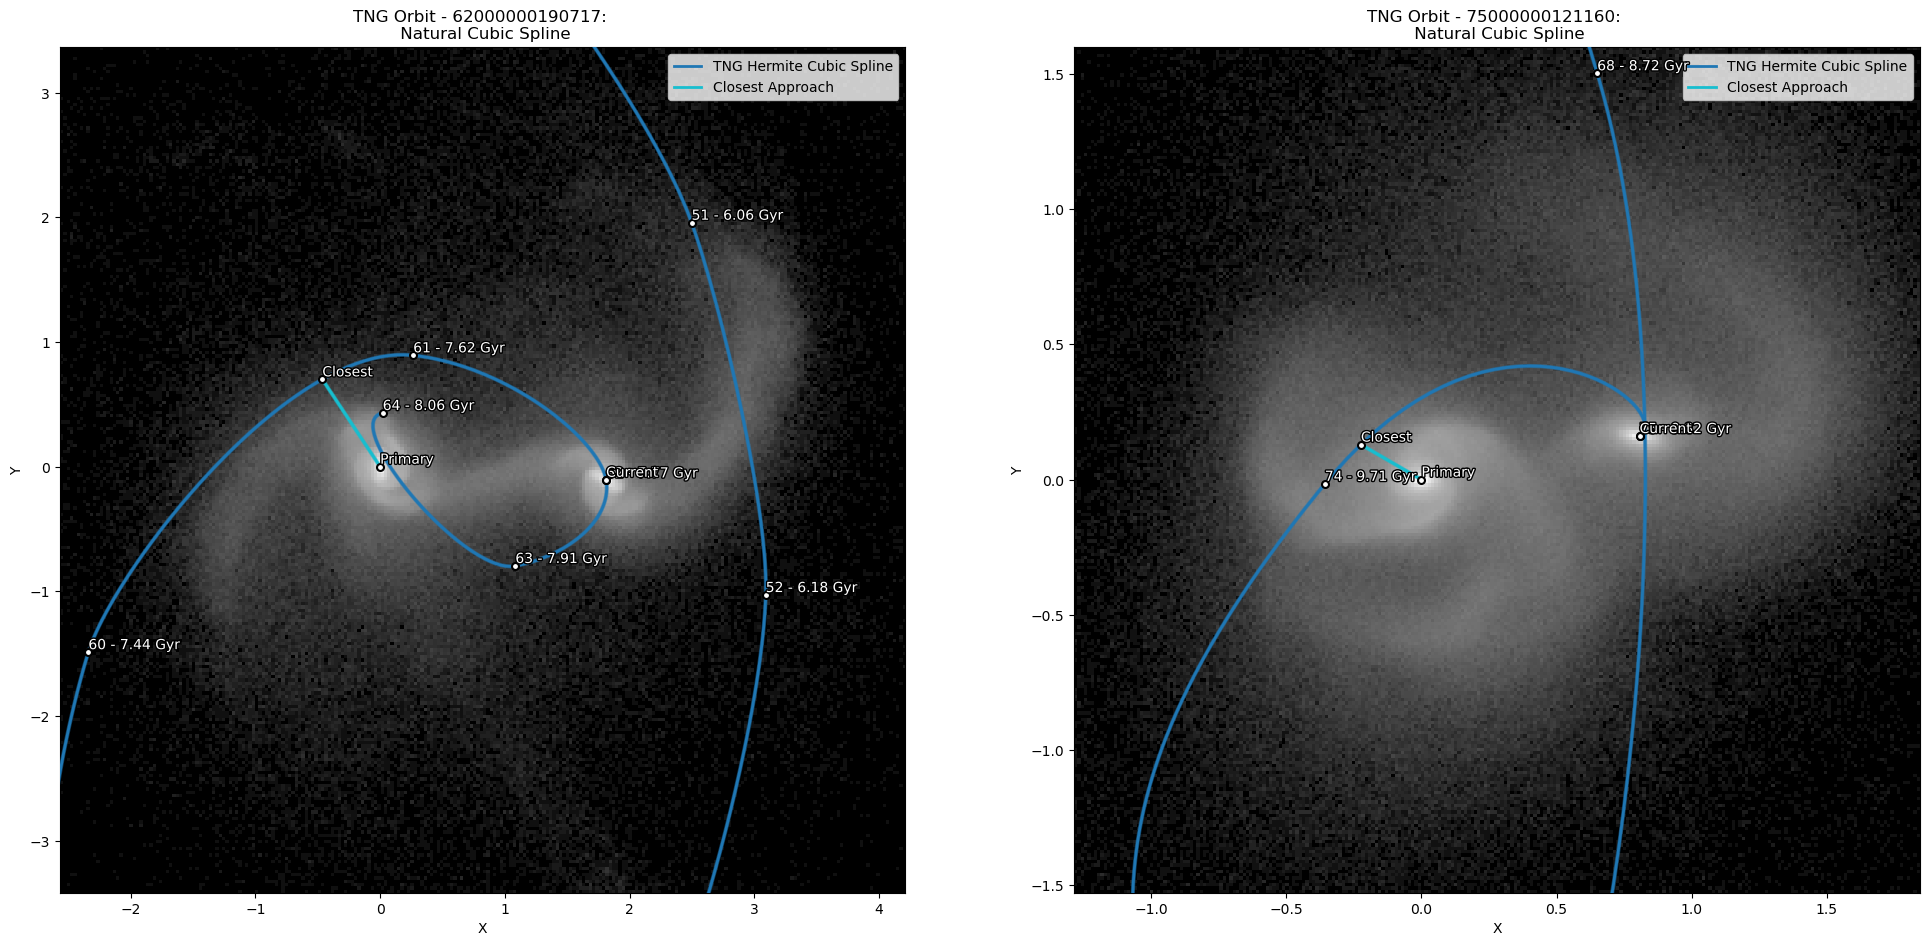

In [ ]:

if buildEnv:
    p1 = 62000000190717 
    p2 = 75000000121160 
    # print(good_targets.columns)

    tng_target_1 = cts.get_tng_target_orbit( p1, dev_print = False, )
    tng_target_2 = cts.get_tng_target_orbit( p2, dev_print = False )
    
    tng_target_1['pts'] = cts.get_tng_target_pts( tng_target_1['current_info'], dev_print = False )
    tng_target_2['pts'] = cts.get_tng_target_pts( tng_target_2['current_info'], dev_print = False )
    
    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    print( tng_target_1['current_info']['p_SubhaloIDRaw'])

    print("Done")
    
    # Feed one plot to each subplot with the same pts data
    tf.xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotate_data= tng_target_1['annotate_data'],
        title = f"TNG Orbit - {tng_target_1['current_info']['p_SubhaloIDRaw']}:",
        ext_ax = axs[0]
    )

    tf.xy_histogram( \
        tng_target_2['pts'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotate_data= tng_target_2['annotate_data'],
        title = f"TNG Orbit - {tng_target_2['current_info']['p_SubhaloIDRaw']}:",
        ext_ax = axs[1]
    )

    plt.show()

---
---
# Orbit Similarity Weight Function
While trying to find a fitness function for comparing the TNG and SPAM simulation, I came across 2 glaring issues:
1) The SPAM simulation ends early if galaxies are not likely to merge.
2) The SPAM and TNG starting parameters are identical by design.  Thus what little SPAM orbit there is to compare is very close to the TNG orbit. 

Thus I have come up with two potential solutions to correct fitness function of orbit similarity
1) **Weighted Fitness Function** - Give more importance to the moment of closest approach
2) **Assymetric Fitness Function** - Penalize the SPAM orbit for ending early

---
---

### Weighted Fitness Function
Accordinging literature, the tidal features of merging galaxies are highly influenced by the moment of closest approach (when the two galaxies are closest, aka fly-by event).  Thus, we can weight the fitness function to give more importance to our orbit at the moment of closest approach.  


I also built in a way to skew the weights up or down before the moment of closest approach occurs.  While I may not use this, I left it here in case I wanted to run an experiment to see if SPAM can model the orbit accurately even further back in time.  

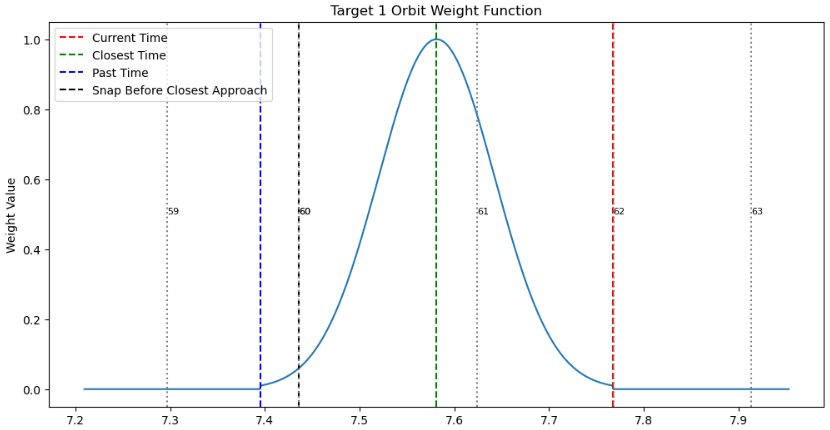

In [ ]:
def gen_orbit_weight_func_of_closest_approach( tng_orbit, boundary_value = 0.01, scale_past = 1.0 ):
    """
    Generate weight related variables and a gaussian function centered on the moment of closest approach.
    Meant to weigh a fitness function comparing TNG and SPAM orbits.
    The weighting function will be zero outside of the past and current times of the orbit.

    path: dict - Accumlated orbit path information for a particular TNG target
    weight_boundary: float (0,1) - The value of the weighting function at current time.
    before_scale: float - Scale the weighting function for times before the closest approach.
    """

    # Build return dictionary containing variables and weight function
    weight_dict = {}

    # Store useful variables for later
    weight_dict['boundary_value'] = boundary_value
    weight_dict['scale_past'] = scale_past
    weight_dict['delta_time'] = tng_orbit['current_time'] - tng_orbit['closest_time']   # Time difference between closest and current time
    weight_dict['weight_start_time'] = tng_orbit['closest_time'] - weight_dict['delta_time'] * scale_past

    # Weight function variables
    start_time = weight_dict['weight_start_time']
    closest_time = tng_orbit['closest_time']
    current_time = tng_orbit['current_time']
    gaussian_weight_after = - ( weight_dict['delta_time']**2 / (2 * np.log( boundary_value ) ) )
    gaussian_weight_before = - ( (scale_past*weight_dict['delta_time'])**2 / (2 * np.log( boundary_value ) ) )

    def weight_func( time, tng_orbit ):
        """
        Generate the weight for a given time
        """

        # If a list or array, recursively apply the function to each element
        if isinstance(time, list) or isinstance(time, np.ndarray):
            return np.array([ weight_func( t, tng_orbit ) for t in time ])

        # If outside of weight range, return 0
        if time < start_time:    return 0
        elif time > current_time:    return 0

        # between closest and current time
        elif time > closest_time:    
            return np.exp( -( (time - closest_time)**2 / (2*gaussian_weight_after) ) )

        # else between start and closest time
        else:    
            return np.exp( -( (time - closest_time)**2 / (2*gaussian_weight_before) ) )
    
    weight_dict['weight_function'] = weight_func
    
    return weight_dict

def plot_weight_function( path, weight_dict, times_ar = None, title = "Orbit Weight Function" ):
    """
    Plot the weight function for the given path
    """

    # Convert test_times to tng_units for plotting
    test_times_tng = cts.convert_time_spam_to_tng( test_times )

    # Get list of idx of times_su that fall in this range
    snap_idx = np.where( (path['times_su'] > start_time) & (path['times_su'] < end_time) )[0]

    plt.plot( test_times_tng, test_weights )

    plt.title(title)
    plt.xlabel("Time (Gyr)")
    plt.ylabel("Weight Value")

    # Add vertical dash lines for current, past, and closest times
    plt.axvline( cts.convert_time_spam_to_tng( path['current_time']), color='r', linestyle='--', label='Current Time' )
    plt.axvline( cts.convert_time_spam_to_tng( path['closest_time']), color='g', linestyle='--', label='Closest Time' )
    # plt.axvline( cts.convert_time_spam_to_tng( path['past_time']), color='b', linestyle='--', label='Past Time' )
    plt.axvline( cts.convert_time_spam_to_tng( start_weight_time ), color='b', linestyle='--', label='Start Weight Time' )

    # Show time of snap before closest approach
    plt.axvline( cts.convert_time_spam_to_tng( path['before_closest_approach_time']), color='k', linestyle='--', label='Snap Before Closest Approach' )
    plt.text( cts.convert_time_spam_to_tng( path['before_closest_approach_time']), 0.5, f"{path['before_closest_approach_snap']}", rotation=0, fontsize=8 )
    
    # Add Mark of axis for the times that are in the range
    snap_list = []
    for i in snap_idx:
        snap_list.append( path['snaps'][i] )
        plt.axvline( cts.convert_time_spam_to_tng( path['times_su'][i]), color='grey', linestyle=':', )
        plt.text( cts.convert_time_spam_to_tng( path['times_su'][i]), 0.5, f"{path['snaps'][i]}", rotation=0, fontsize=8 )

    # Make plot bigger
    plt.gcf().set_size_inches(12, 6)

    # Legend
    plt.legend()
    plt.show()
    
if buildEnv:
    logger.setLevel(logging.INFO)

    weights1 = {}
    for scale_past in [1.0, 6.0]:
        print( scale_past)
        weights1[scale_past] = gen_orbit_weight_func_of_closest_approach( r1, boundary_value = 0.01, scale_past = scale_past )
    
    # plot_weight_function( path1, scale_past = 1.0, title="Target 1 Orbit Weight Function" )
    # plot_weight_function( path1, scale_past = 5.0, title="Target 1 Skewed Weight Function" )
    # plot_weight_function( path2, scale_past = 1.0, title="Target 2 Orbit Weight Function" )
    # print("Done")

    # # Get axis for a plot
    # fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # # Feed one plot to each subplot with the same pts data
    # tf.xy_histogram( \
    #     pts1, \
    #     path1['plot_list'], path1['plot_labels'], \
    #     show_labels = True, std_dev = 3,
    #     annotate_data= path1['annotate_data'],
    #     title = f'TNG Orbit - {r1["p_SubhaloIDRaw"]}: \n Natural Cubic Spline',
    #     ext_ax = ax
    # )


    

1.0


KeyError: 'current_time'

In [ ]:


def plot_weight_function( path, weight_func, dev_print = False, title="Weight Funtion for Orbit Similarity" ):

    # Verify the weight function does as I expect.  plot the weight values between adn around current, past, and closest times
    d_time = path['current_time'] - path['past_time']
    min_time = path['past_time'] - d_time/2
    max_time = path['current_time'] + d_time/2

    test_times = np.linspace( min_time, max_time, 1000 )
    test_weights = path['weight_func']( test_times )
    
    # Covert test_times to tng units
    test_times_tng = convert_time_spam_to_tng( test_times )

In [ ]:


if buildEnv:

    plot_weight_function( path1, dev_print = True, title= 'Weights for: %d' % p1 )
    plot_weight_function( path2, dev_print = True, title= 'Weights for: %d' % p2 ) 


TypeError: plot_weight_function() missing 1 required positional argument: 'weight_func'

In [ ]:
if buildEnv:
    
    # Empty items default to SPAM Default
    spam_param_default = { 'label':"Default SPAM Params" }

    # Misleading Orbit Parameters
    spam_param_off_time = {
        'mhalo': 10, 'lnl': 0.05,
        'label': 'Time  SPAM Params'
    }

    # This is a hand discovered SPAM parameter set that appears to be a good match
    spam_param_hand = {
        'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
        'label': 'Hand-found SPAM Params'
    }